In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Exercise 1: ranking by linear correlation coefficient

In [2]:
# import data
cols = ["species", "specimen_number", "eccentricity", "aspect_ratio", "elongation", "solidity", 
           "stochastic_convexity", "isoperimetric_factor", "max_indent_depth", "lobedness", 
           "avg_intensity", "avg_contrast", "smoothness", "third_moment", "uniformity", "entropy"]
leaves_df = pd.read_csv("data/leaf/leaf.csv", names=cols)
leaves_df.head()

,species,specimen_number,eccentricity,aspect_ratio,elongation,solidity,stochastic_convexity,isoperimetric_factor,max_indent_depth,lobedness,avg_intensity,avg_contrast,smoothness,third_moment,uniformity,entropy
0,1,1,0.72694,1.4742,0.32396,0.98535,1.00000,0.83592,0.004657,0.003947,0.047790,0.127950,0.016108,0.005232,0.000275,1.17560
1,1,2,0.74173,1.5257,0.36116,0.98152,0.99825,0.79867,0.005242,0.005002,0.024160,0.090476,0.008119,0.002708,0.000075,0.69659
2,1,3,0.76722,1.5725,0.38998,0.97755,1.00000,0.80812,0.007457,0.010121,0.011897,0.057445,0.003289,0.000921,0.000038,0.44348
3,1,4,0.73797,1.4597,0.35376,0.97566,1.00000,0.81697,0.006877,0.008607,0.015950,0.065491,0.004271,0.001154,0.000066,0.58785
4,1,5,0.82301,1.7707,0.44462,0.97698,1.00000,0.75493,0.007428,0.010042,0.007938,0.045339,0.002051,0.000560,0.000024,0.34214


In [3]:
# define function to compute linear correlation coefficient
def linear_correlation(col1, col2):
    d1 = col1 - np.mean(col1)
    d2 = col2 - np.mean(col2)
    v1 = np.sum(np.square(d1))
    v2 = np.sum(np.square(d2))
    cov = np.sum(np.multiply(d1,d2))
    return cov/np.sqrt(v1*v2)

In [4]:
# check agreement with numpy value (up to machine precision)
print(f"Manual implementation: {linear_correlation(leaves_df['species'], leaves_df['eccentricity'])}")
print(f"Numpy implementation:  {np.corrcoef(leaves_df['species'], leaves_df['eccentricity'])[0][1]}")

Manual implementation: 0.09141460302089632
Numpy implementation:  0.09141460302089631


In [5]:
# compute linear correlation to rank dataset features (against class)
_ranks = []
_cols  = leaves_df.columns[1:]
for feature in _cols:
    _ranks.append(linear_correlation(leaves_df['species'], leaves_df[feature]))
    
idx = np.argsort(_ranks)[::-1]
for i in idx:
    print(f"{_cols[i]: <30}: {_ranks[i]}")

aspect_ratio                  : 0.27521011784907834
uniformity                    : 0.18771684999019725
elongation                    : 0.1412752472957704
solidity                      : 0.11184290470599256
avg_intensity                 : 0.10245321896478975
smoothness                    : 0.09488520535309278
eccentricity                  : 0.09141460302089632
avg_contrast                  : 0.07624645270769874
third_moment                  : 0.05852012269141438
stochastic_convexity          : 0.046678319203711044
entropy                       : 0.017690039653981846
specimen_number               : -0.015142016547326385
lobedness                     : -0.01704805059413959
max_indent_depth              : -0.04002558235513151
isoperimetric_factor          : -0.049766613170472276


## Exercise 2: ranking by mutual information

In [6]:
# import data
cols = ["class", "handicapped_infants", "water_project_cost_sharing", "adoption_budget_resolution",
        "physician_fee_freeze", "el_salvador_aid", "religious_groups_in_school", "anti_satellite_test_ban",
        "aid_nicaraguan_contras", "mx_missile", "immigration", "synfuels_corporation_cutback", 
        "education_spending", "superfund_right_to_sue", "crime", "duty_free_exports", 
        "export_administration_act_SA"
       ]
votes_df = pd.read_csv("data/votes/house-votes-84.data", names=cols)
votes_df.head()

,class,handicapped_infants,water_project_cost_sharing,adoption_budget_resolution,physician_fee_freeze,el_salvador_aid,religious_groups_in_school,anti_satellite_test_ban,aid_nicaraguan_contras,mx_missile,immigration,synfuels_corporation_cutback,education_spending,superfund_right_to_sue,crime,duty_free_exports,export_administration_act_SA
0,republican,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
2,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
3,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
4,democrat,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y


In [7]:
def mutual_info(df, target_col, feature_col):
    # get target col probs
    target_vals = df[target_col].unique()
    target_prob = df[target_col].value_counts() / df.shape[0]
    # get feature col probs
    feature_vals = df[feature_col].unique()
    feature_prob = df[feature_col].value_counts() / df.shape[0]
    # get conditional probs
    mixed_prob = df.groupby(by=[target_col,feature_col]).agg(
        counts = (feature_col, pd.Series.count)
    ) / df.shape[0]
    
    # compute mutual info
    mutual_info = 0.0
    for target in target_vals:
        for feature in feature_vals:
            idx = (target,feature)
            mutual_info += mixed_prob.loc[idx]['counts'] * np.log(mixed_prob.loc[idx]['counts']/ \
                                                  (feature_prob[feature]*target_prob[target]))
    
    return mutual_info

In [8]:
# test function against scikit implementation
from sklearn.feature_selection import mutual_info_classif
class_to_int = votes_df['class'].apply(lambda x: 1.0 if x=='republican' else 0.0).to_numpy()
feat_to_int = votes_df['handicapped_infants'].apply(lambda x: 2.0 if x=='?' else (1.0 if x=='y' else 0.0)).to_numpy()
feat_to_int = feat_to_int[:,np.newaxis]

print(f"Manual implementation: {mutual_info(votes_df, target_col='class', feature_col='handicapped_infants')}")
print(f"Scikit implementation: {mutual_info_classif(feat_to_int, class_to_int, discrete_features=True)[0]}")

Manual implementation: 0.08738722927832451
Scikit implementation: 0.08738722927832443


Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [9]:
# compute mutual information to rank dataset features (against class)
_ranks = []
_cols  = votes_df.columns[1:]
for feature in _cols:
    _ranks.append(mutual_info(votes_df, target_col='class', feature_col=feature))
    
idx = np.argsort(_ranks)[::-1]
for i in idx:
    print(f"{_cols[i]: <30}: {_ranks[i]}")

physician_fee_freeze          : 0.5129515491210119
adoption_budget_resolution    : 0.29966050855502235
el_salvador_aid               : 0.292820363908198
education_spending            : 0.25941112399790134
aid_nicaraguan_contras        : 0.23582647275244228
crime                         : 0.232400928863132
mx_missile                    : 0.21526164558528296
superfund_right_to_sue        : 0.15789963958281852
duty_free_exports             : 0.15277113756241903
anti_satellite_test_ban       : 0.13702350844932737
religious_groups_in_school    : 0.10205527995633651
handicapped_infants           : 0.08738722927832451
synfuels_corporation_cutback  : 0.07436909386118576
export_administration_act_SA  : 0.07068655457934098
immigration                   : 0.003522481150227346
water_project_cost_sharing    : 0.00024996231558368576


## Exercise 3: PCA

In [10]:
iono_df = pd.read_csv("data/ionosphere/ionosphere.data")
cols =  [ f'real_{i//2}' if i%2==0 else f'imaginary_{i//2}' for i in range(0,34)] + ['class']
iono_df.columns = cols
iono_df

,real_0,imaginary_0,real_1,imaginary_1,real_2,imaginary_2,real_3,imaginary_3,real_4,imaginary_4,...,imaginary_12,real_13,imaginary_13,real_14,imaginary_14,real_15,imaginary_15,real_16,imaginary_16,class
0,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
1,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
2,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
3,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g
4,1,0,0.02337,-0.00592,-0.09924,-0.11949,-0.00763,-0.11824,0.14706,0.06637,...,-0.01535,-0.03240,0.09223,-0.07859,0.00732,0.00000,0.00000,-0.00039,0.12011,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,1,0,0.83508,0.08298,0.73739,-0.14706,0.84349,-0.05567,0.90441,-0.04622,...,-0.04202,0.83479,0.00123,1.00000,0.12815,0.86660,-0.10714,0.90546,-0.04307,g
346,1,0,0.95113,0.00419,0.95183,-0.02723,0.93438,-0.01920,0.94590,0.01606,...,0.01361,0.93522,0.04925,0.93159,0.08168,0.94066,-0.00035,0.91483,0.04712,g
347,1,0,0.94701,-0.00034,0.93207,-0.03227,0.95177,-0.03431,0.95584,0.02446,...,0.03193,0.92489,0.02542,0.92120,0.02242,0.92459,0.00442,0.92697,-0.00577,g
348,1,0,0.90608,-0.01657,0.98122,-0.01989,0.95691,-0.03646,0.85746,0.00110,...,-0.02099,0.89147,-0.07760,0.82983,-0.17238,0.96022,-0.03757,0.87403,-0.16243,g


In [11]:
# get data as numpy matrix
iono_arr = iono_df.iloc[:,:-1].to_numpy()
iono_arr

array([[ 1.     ,  0.     ,  1.     , ..., -0.06288, -0.13738, -0.02447],
       [ 1.     ,  0.     ,  1.     , ..., -0.2418 ,  0.56045, -0.38238],
       [ 1.     ,  0.     ,  1.     , ...,  1.     , -0.32382,  1.     ],
       ...,
       [ 1.     ,  0.     ,  0.94701, ...,  0.00442,  0.92697, -0.00577],
       [ 1.     ,  0.     ,  0.90608, ..., -0.03757,  0.87403, -0.16243],
       [ 1.     ,  0.     ,  0.8471 , ..., -0.06678,  0.85764, -0.06151]])

In [12]:
def covariance_matrix(data):
    diffs = data - data.mean(axis=0) # subtract mean from each observation
    return diffs.transpose() @ diffs / diffs.shape[0] # compute cov matrix

def pca_dims_plot(data):
    cov_matrix = covariance_matrix(data) # compute cov matrix
    eigvals = np.sort(np.linalg.eigvals(cov_matrix))[::-1] # compute eigenvecs
    plt.semilogy(range(eigvals.shape[0]), eigvals, 'ob')
    plt.title("pricipal components eigenvalues")
    plt.xlabel(r"$\lambda$ number")
    plt.ylabel(r"$\lambda$")
    return 

def pca_projection(data, dims=2):
    cov_matrix = covariance_matrix(data) # compute cov matrix
    eigvals, eigvecs = np.linalg.eig(cov_matrix) # compute eigenvecs
    eigvecs = eigvecs[:,np.argsort(eigvals)[::-1]] # sort by eigenval 
    return data @ eigvecs[:dims].transpose()

In [13]:
# check against scikit implementation
from sklearn.covariance import EmpiricalCovariance

mycov = covariance_matrix(iono_arr)
scikit = EmpiricalCovariance().fit(iono_arr).covariance_

# check agreement (up to machine precision)
for i in range(mycov.shape[0]):
    for j in range(mycov.shape[1]):
        if abs(mycov[i,j] - scikit[i,j]) > 1.0e-16:
            print(f"Element {i},{j} is different")

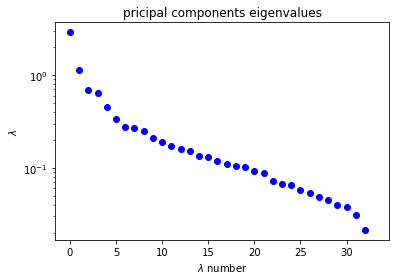

In [14]:
# now cerforming a PCA on the dataset
pca_dims_plot(iono_arr) # first check the best number of dims for reduction

(350, 2)


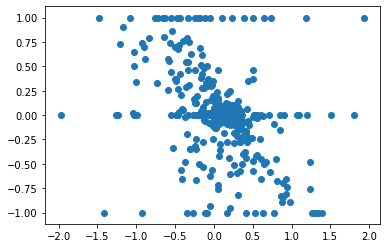

In [15]:
# perform the PCA to two dimensions and plot data
reduced_iono_arr = pca_projection(iono_arr, dims=2)
print(reduced_iono_arr.shape)
plt.scatter(reduced_iono_arr[:,0], reduced_iono_arr[:,1])

## Exercise 4: distances and similarities

In [16]:
# various distances

def mahalanobis_dist(x_i, x_j, cov_matrix):
    dx = (x_i - x_j)
    return np.sqrt(dx.transpose() @ np.linalg.inv(cov_matrix) @ dx)

def euclidean_dist(x_i, x_j):
    dx = x_i - x_j
    return np.sqrt(np.dot(dx, dx))

def hamming_distance(obs_i, obs_j):
    return (obs_i != obs_j).sum()

#### Testing mahalanobis distance

In [17]:
# get cov matrix for leaves dataset
cov_mat = covariance_matrix(leaves_df.to_numpy())

In [18]:
from scipy.spatial.distance import mahalanobis
print(f"Manual: {mahalanobis_dist(leaves_df.iloc[1], leaves_df.iloc[2], cov_mat)}")
print(f"Scipy : {mahalanobis(leaves_df.iloc[1], leaves_df.iloc[2], np.linalg.inv(cov_mat))}")

Manual: 1.8415404397351183
Scipy : 1.8415404397351183


#### Testing euclidean distance

In [19]:
print(f"Manual: {euclidean_dist(iono_arr[1], iono_arr[2])}")
print(f"Numpy : {np.linalg.norm(iono_arr[1] - iono_arr[2])}")

Manual: 4.671267441562301
Numpy : 4.671267441562301


#### Testing hamming distance

In [20]:
votes_df.iloc[1:3] # manually compute number of different fields -> 5

,class,handicapped_infants,water_project_cost_sharing,adoption_budget_resolution,physician_fee_freeze,el_salvador_aid,religious_groups_in_school,anti_satellite_test_ban,aid_nicaraguan_contras,mx_missile,immigration,synfuels_corporation_cutback,education_spending,superfund_right_to_sue,crime,duty_free_exports,export_administration_act_SA
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
2,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n


In [21]:
from scipy.spatial.distance import hamming
print(f"Manual: {hamming_distance(votes_df.iloc[1], votes_df.iloc[2])}") # compute using defined distance
print(f"Scipy : {hamming(votes_df.iloc[1], votes_df.iloc[2])*len(votes_df.iloc[1])}")

Manual: 7
Scipy : 7.0
